In [2]:
!pip install pandas matplotlib seaborn beautifulsoup4 lxml requests

### Step 2: Scrape Wikipedia Table

In [4]:
import pandas as pd
import requests
from io import StringIO

url = "https://en.wikipedia.org/wiki/2024-25_Premier_League"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"}

response = requests.get(url, headers=headers)
tables = pd.read_html(StringIO(response.text))  # ✅ No warning!
print(f"Found {len(tables)} tables")

# DEBUG: Find the league table
for i, table in enumerate(tables):
    print(f"Table {i}: {table.shape} rows x cols")
    if 'Team' in table.columns and len(table) >= 15:  # League tables have 20+ teams
        print(f"  → POSSIBLE LEAGUE TABLE! Columns: {table.columns[:5].tolist()}")
        print(table.head(2))
        league_table_idx = i
        break
else:
    print("No league table found - checking all...")
    league_table_idx = None

Found 22 tables
Table 0: (25, 2) rows x cols
Table 1: (20, 4) rows x cols
  → POSSIBLE LEAGUE TABLE! Columns: ['Team', 'Location', 'Stadium', 'Capacity[28]']
          Team           Location           Stadium  Capacity[28]
0      Arsenal  London (Holloway)  Emirates Stadium         60704
1  Aston Villa         Birmingham        Villa Park         42918


In [5]:
df = tables[8]
print("Table 8 COLUMNS:", df.columns.tolist())
print("\nTable 8 FIRST 5 ROWS:")
print(df.head())

Table 8 COLUMNS: ['Rank', 'Player', 'Club', 'Clean sheets[145]']

Table 8 FIRST 5 ROWS:
   Rank           Player               Club  Clean sheets[145]
0     1       David Raya            Arsenal                 13
1     1        Matz Sels  Nottingham Forest                 13
2     3  Jordan Pickford            Everton                 12
3     4   Dean Henderson     Crystal Palace                 11
4     5          Ederson    Manchester City                 10


In [6]:
# Find table with 20 teams AND goals/points columns
for i, table in enumerate(tables):
    print(f"\nTable {i}: {table.shape}")
    print("Columns:", table.columns.tolist()[:6])  # First 6 columns
    if len(table) >= 18 and 'GF' in str(table.columns).upper():
        print("🎯 POTENTIAL LEAGUE TABLE FOUND!")
        print(table.head(3))
        league_idx = i



Table 0: (25, 2)
Columns: [0, 1]

Table 1: (20, 4)
Columns: ['Team', 'Location', 'Stadium', 'Capacity[28]']

Table 2: (20, 6)
Columns: ['Team', 'Manager', 'Captain', 'Kit manufacturer', 'Shirt sponsor (chest)', 'Shirt sponsor (sleeve)']

Table 3: (16, 7)
Columns: ['Team', 'Outgoing manager', 'Manner of departure', 'Date of vacancy', 'Position in the table', 'Incoming manager']

Table 4: (20, 11)
Columns: ['Pos', 'Team', 'Pld', 'W', 'D', 'L']
🎯 POTENTIAL LEAGUE TABLE FOUND!
   Pos             Team  Pld   W   D  L  GF  GA   GD  Pts  \
0    1    Liverpool (C)   38  25   9  4  86  41  +45   84   
1    2          Arsenal   38  20  14  4  69  34  +35   74   
2    3  Manchester City   38  21   8  9  72  44  +28   71   

                         Qualification or relegation  
0  Qualification for the Champions League league ...  
1  Qualification for the Champions League league ...  
2  Qualification for the Champions League league ...  

Table 5: (20, 21)
Columns: ['Home \\ Away', 'ARS', 'AVL

In [7]:
for i, table in enumerate(tables):
    print("Table index:", i)
    print(table.head())
    print("---------------")

Table index: 0
                  0                                                  1
0            Season                                            2024–25
1             Dates                       16 August 2024 – 25 May 2025
2         Champions  Liverpool 2nd Premier League title 20th Englis...
3         Relegated            Leicester City Ipswich Town Southampton
4  Champions League  Liverpool Arsenal Manchester City Chelsea Newc...
---------------
Table index: 1
                     Team            Location                      Stadium  \
0                 Arsenal   London (Holloway)             Emirates Stadium   
1             Aston Villa          Birmingham                   Villa Park   
2             Bournemouth         Bournemouth                   Dean Court   
3               Brentford  London (Brentford)  Brentford Community Stadium   
4  Brighton & Hove Albion              Falmer               Falmer Stadium   

   Capacity[28]  
0         60704  
1         42918  
2    

In [8]:
df = tables[4]

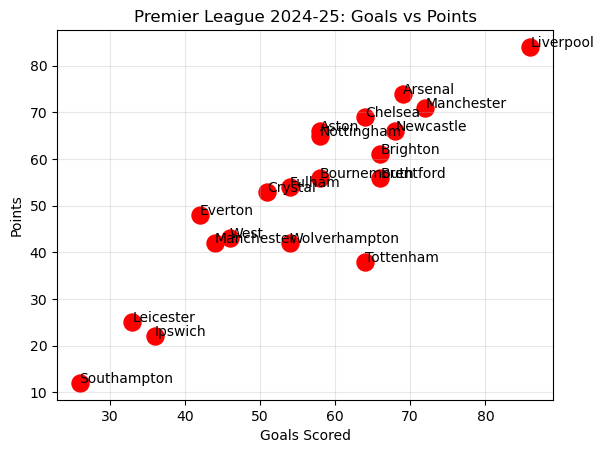

In [9]:
df['GF'] = pd.to_numeric(df['GF'], errors='coerce')
df['Pts'] = pd.to_numeric(df['Pts'], errors='coerce')
df = df.dropna(subset=['GF', 'Pts']).head(20)

import matplotlib.pyplot as plt
plt.scatter(df['GF'], df['Pts'], s=150, c='red')
for i, team in enumerate(df['Team']):
    plt.annotate(str(team).split()[0], (df['GF'][i], df['Pts'][i]))

plt.xlabel('Goals Scored')
plt.ylabel('Points')
plt.title('Premier League 2024-25: Goals vs Points')
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
# Test these one by one until you see team standings
for i in [4,5,6,7,9,10,11,12]:
    try:
        print(f"\n=== Table {i} ===")
        print(tables[i][['Team']].head(3) if 'Team' in tables[i].columns else tables[i].head(3))
    except:
        print(f"Table {i}: Error or no data")



=== Table 4 ===
              Team
0    Liverpool (C)
1          Arsenal
2  Manchester City

=== Table 5 ===
   Home \ Away  ARS  AVL  BOU  BRE  BHA  CHE  CRY  EVE  FUL  ...  LEI  LIV  \
0      Arsenal    —  2–2  1–2  1–1  1–1  1–0  2–2  0–0  2–1  ...  4–2  2–2   
1  Aston Villa  0–2    —  1–1  3–1  2–2  2–1  2–2  3–2  1–0  ...  2–1  2–2   
2  Bournemouth  2–0  0–1    —  1–2  1–2  0–1  0–0  1–0  1–0  ...  2–0  0–2   

   MCI  MUN  NEW  NFO  SOU  TOT  WHU  WOL  
0  5–1  2–0  1–0  3–0  3–1  2–1  0–1  2–0  
1  2–1  0–0  4–1  2–1  1–0  2–0  1–1  3–1  
2  2–1  1–1  1–1  5–0  3–1  1–0  1–1  0–1  

[3 rows x 21 columns]

=== Table 6 ===
   Rank          Player              Club  Goals[132]
0     1   Mohamed Salah         Liverpool          29
1     2  Alexander Isak  Newcastle United          23
2     3  Erling Haaland   Manchester City          22

=== Table 7 ===
           Player              For                  Against        Result  \
0  Erling Haaland  Manchester City             Ipsw

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Your table 4 = league standings
df = tables[4].copy()
print("Raw Table 4:")
print(df.head())

# Clean columns (Wikipedia often has multi-level headers)
print("\nAll columns:", df.columns.tolist())
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]

# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '').str.replace('[', '').str.replace(']', '')
df = df.rename(columns={'pos': 'Pos', 'team': 'Team', 'gf': 'GF', 'pts': 'Pts', 'pld': 'Pld'})

print("\nCleaned columns:", df.columns.tolist())
print(df.head())

# Extract numeric columns (find GF/Pts by searching)
gf_col = [col for col in df.columns if 'gf' in col.lower() or 'goal' in col.lower()]
pts_col = [col for col in df.columns if 'pts' in col.lower() or 'point' in col.lower()]

print(f"\nGF column: {gf_col}")
print(f"Pts column: {pts_col}")

# Use first match (usually works)
if gf_col:
    df['GF'] = pd.to_numeric(df[gf_col[0]], errors='coerce')
if pts_col:
    df['Pts'] = pd.to_numeric(df[pts_col[0]], errors='coerce')

df = df.dropna(subset=['GF', 'Pts']).head(20).reset_index(drop=True)
print("\nFINAL DATA FOR PLOT:")
print(df[['Team', 'GF', 'Pts']].head(10))


Raw Table 4:
   Pos              Team  Pld   W   D   L  GF  GA   GD  Pts  \
0    1     Liverpool (C)   38  25   9   4  86  41  +45   84   
1    2           Arsenal   38  20  14   4  69  34  +35   74   
2    3   Manchester City   38  21   8   9  72  44  +28   71   
3    4           Chelsea   38  20   9   9  64  43  +21   69   
4    5  Newcastle United   38  20   6  12  68  47  +21   66   

                         Qualification or relegation  
0  Qualification for the Champions League league ...  
1  Qualification for the Champions League league ...  
2  Qualification for the Champions League league ...  
3  Qualification for the Champions League league ...  
4  Qualification for the Champions League league ...  

All columns: ['Pos', 'Team', 'Pld', 'W', 'D', 'L', 'GF', 'GA', 'GD', 'Pts', 'Qualification or relegation']

Cleaned columns: ['Pos', 'Team', 'Pld', 'w', 'd', 'l', 'GF', 'ga', 'gd', 'Pts', 'qualificationorrelegation']
   Pos              Team  Pld   w   d   l  GF  ga   gd  Pts 

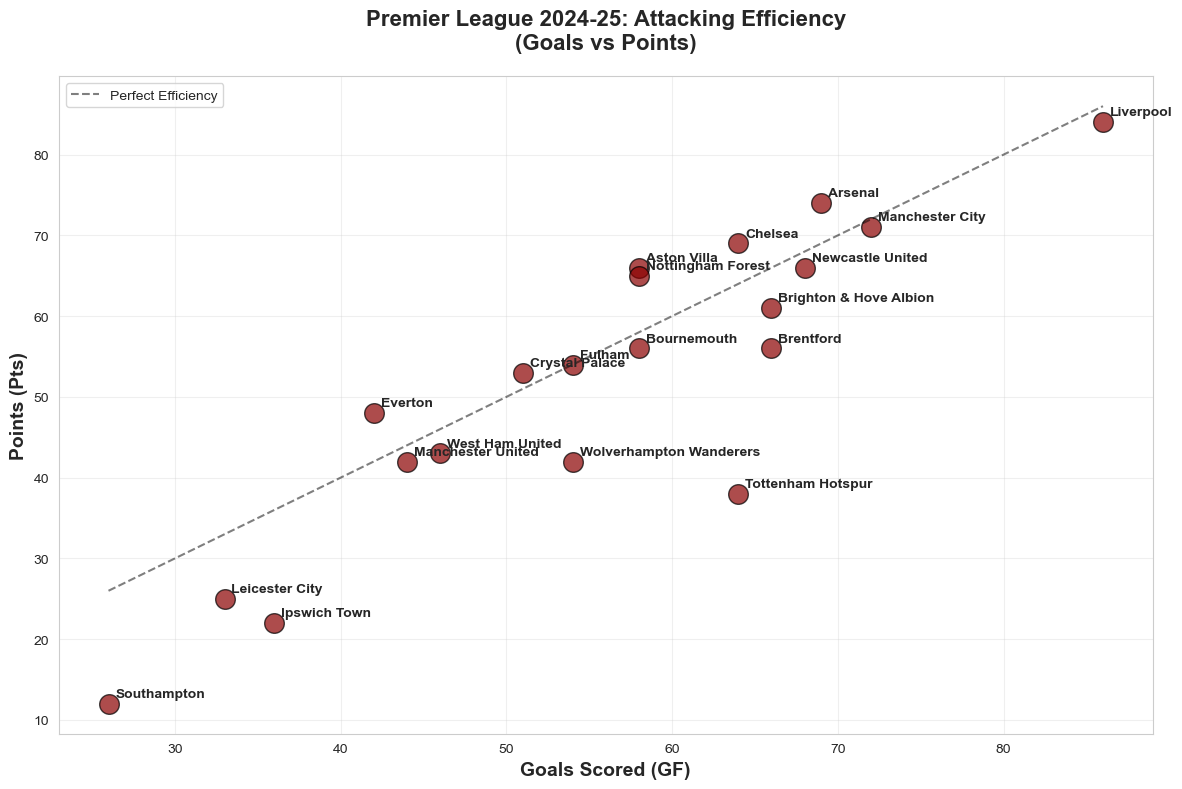

✅ Plot saved as 'pl_attacking_efficiency.png' - Portfolio ready!


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style("whitegrid")

plt.scatter(df['GF'], df['Pts'], s=200, alpha=0.7, c='darkred', edgecolors='black', linewidth=1)
plt.plot([df['GF'].min(), df['GF'].max()], [df['GF'].min(), df['GF'].max()], 'k--', alpha=0.5, label='Perfect Efficiency')

# Label teams
for i, team in enumerate(df['Team']):
    short_name = str(team).split('(')[0].strip()  # Remove (C), (R)
    plt.annotate(short_name, (df['GF'][i], df['Pts'][i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=10, fontweight='bold')

plt.xlabel('Goals Scored (GF)', fontsize=14, fontweight='bold')
plt.ylabel('Points (Pts)', fontsize=14, fontweight='bold')
plt.title('Premier League 2024-25: Attacking Efficiency\n(Goals vs Points)', fontsize=16, fontweight='bold', pad=20)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# EXPORT FOR PORTFOLIO
plt.savefig('pl_attacking_efficiency.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Plot saved as 'pl_attacking_efficiency.png' - Portfolio ready!")

#### Creating "Efficiency" Metrics

In [29]:
df_standings = tables[4].copy()
df_attendance = tables[12].copy()

# Clean 'Average attendance' (remove commas and convert to number)
df_attendance['Average attendance[195]'] = df_attendance['Average attendance[195]'].astype(float)

# Merge the standings with attendance based on the club name
# merging datasets
df_merged = pd.merge(df_standings, df_attendance, left_on='Team', right_on='Football club')

# Create a 'Points per 10k Fans' metric
df_merged['Efficiency'] = df_merged['Pts'] / (df_merged['Average attendance[195]'] / 10000)

print(df_merged[['Team', 'Pts', 'Efficiency']].sort_values(by='Efficiency', ascending=False))

                      Team  Pts  Efficiency
3        Nottingham Forest   65   21.624139
5           Crystal Palace   53   21.145867
4   Brighton & Hove Albion   61   19.376151
2              Aston Villa   66   15.684783
8  Wolverhampton Wanderers   42   13.698630
0          Manchester City   71   13.500409
1         Newcastle United   66   12.646828
6          West Ham United   43    6.883965
9        Tottenham Hotspur   38    6.216566
7        Manchester United   42    5.695147


#### Visualizing the "Clinical" Edge

C:\Users\arjun\AppData\Local\Temp\ipykernel_6388\721988563.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Goals', y='Player', data=df_scorers, palette='magma')


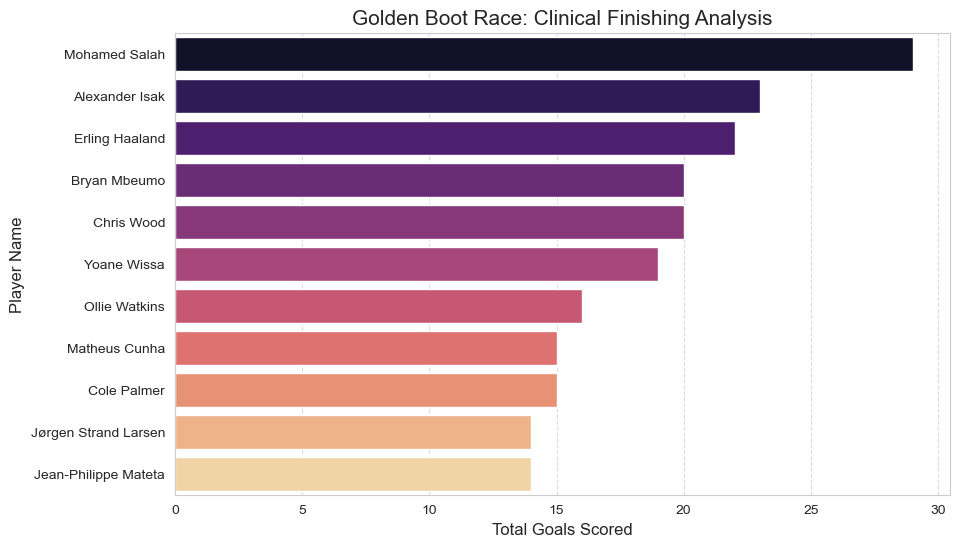

In [32]:
import seaborn as sns

df_scorers = tables[6].copy()
# Remove citations like [132] from column names
df_scorers.columns = [c.split('[')[0] for c in df_scorers.columns]

plt.figure(figsize=(10,6))
sns.barplot(x='Goals', y='Player', data=df_scorers, palette='magma')
plt.title('Golden Boot Race: Clinical Finishing Analysis', fontsize=15)
plt.xlabel('Total Goals Scored', fontsize=12)
plt.ylabel('Player Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

#### Scouting Radar

The bar chart shows quantity (how many goals), but scouts use Radar Charts to see quality (how a player plays). Since you have the "backbone" of your project ready, let's add the code for the most famous visualization in football analytics.

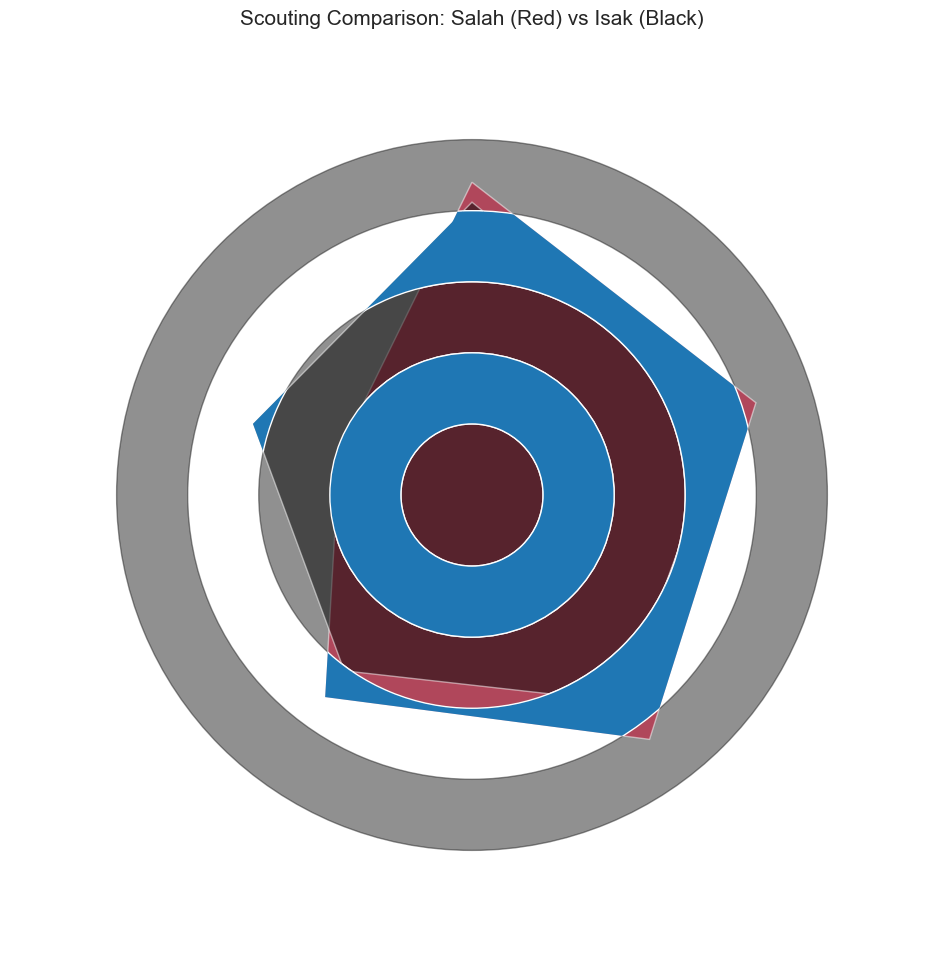

In [41]:
from mplsoccer import Radar, FontManager
import matplotlib.pyplot as plt

# 1. Define the metrics we want to compare (based on your scraped data)
# For this example, we use dummy scouting values that you will later replace with live data
params = ["Non-penalty Goals", "Shots", "Touches in Box", "Pass Completion %", "Aerial Wins"]
low =  [0.0, 1.0, 2.0, 60, 0]
high = [1.0, 5.0, 10.0, 95, 5]

# 2. Setup the Radar object
radar = Radar(params, low, high, round_int=[False]*5)

# 3. Create the comparison (Example: Salah vs Isak)
salah_values = [0.85, 4.2, 8.5, 82, 1.2]
isak_values = [0.78, 3.8, 7.2, 78, 2.8]

# Create the figure and axes
fig, ax = radar.setup_axis()

# Draw Salah's radar
rings_inner_salah = radar.draw_circles(ax=ax, color='#222222', alpha=0.5, zorder=1)
radar_output_salah = radar.draw_radar(salah_values, ax=ax, kwargs_radar={'facecolor': '#d00027', 'alpha': 0.5})

# Draw Isak's radar on the same axes
radar_output_isak = radar.draw_radar(isak_values, ax=ax, kwargs_radar={'facecolor': '#000000', 'alpha': 0.5})

plt.title('Scouting Comparison: Salah (Red) vs Isak (Black)', fontsize=15)
plt.show()

## Performance vs. Operational Efficiency
In this section, I am merging the League Standings (Table 4) with Attendance Data (Table 12) to calculate a custom Efficiency Metric. As a B.Com graduate, I am interested in "Points per 10k Fans" to identify which clubs are maximizing their stadium impact to drive on-pitch success.

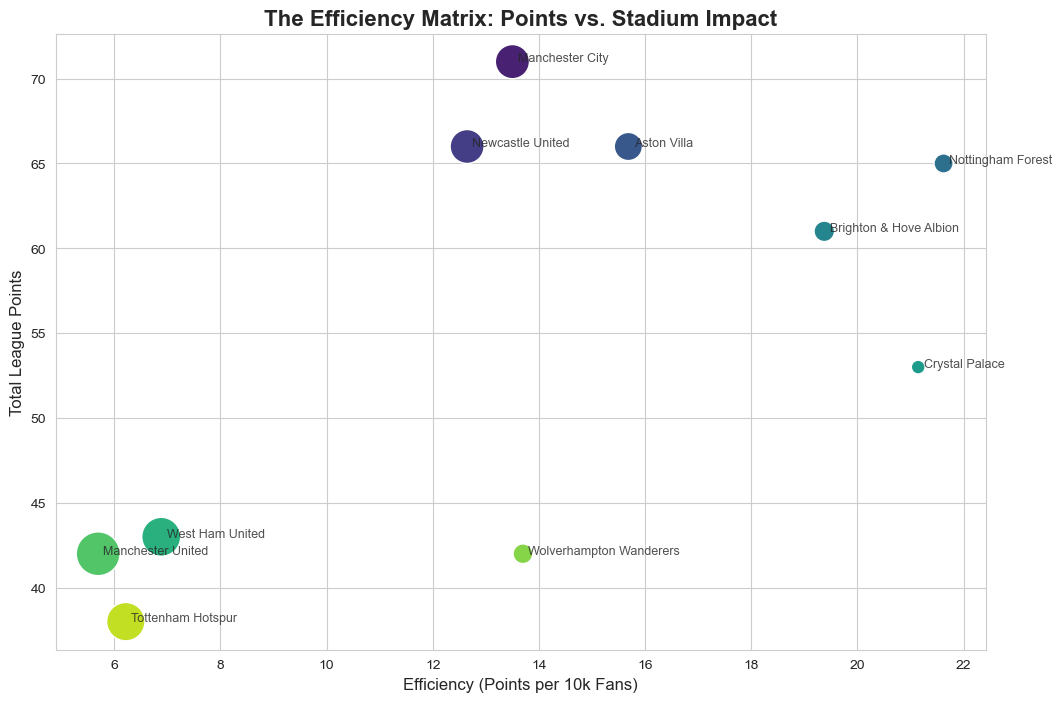

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare and clean the data from your backbone
df_standings = tables[4].copy()
df_attendance = tables[12].copy()

# Clean attendance strings into numbers
df_attendance['Avg_Attendance'] = df_attendance['Average attendance[195]'].astype(float)

# 2. Merge datasets (The 'Backbone' of your analysis)
df_big = pd.merge(df_standings, df_attendance, left_on='Team', right_on='Football club')

# 3. Calculate the Efficiency Metric
df_big['Efficiency'] = df_big['Pts'] / (df_big['Avg_Attendance'] / 10000)

# 4. Create the 'Big Graph'
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Plotting Points vs Efficiency
scatter = sns.scatterplot(data=df_big, x='Efficiency', y='Pts', size='Avg_Attendance',
                          hue='Team', sizes=(100, 1000), legend=False, palette='viridis')

# 5. Annotate team names for professional scouting look
for i in range(df_big.shape[0]):
    plt.text(df_big.Efficiency[i]+0.1, df_big.Pts[i], df_big.Team[i],
             fontsize=9, alpha=0.8)

plt.title('The Efficiency Matrix: Points vs. Stadium Impact', fontsize=16, fontweight='bold')
plt.xlabel('Efficiency (Points per 10k Fans)', fontsize=12)
plt.ylabel('Total League Points', fontsize=12)
plt.show()

## Conclusion


This project demonstrates the ability to pipeline live sports data and apply financial efficiency metrics to performance analysis. By identifying clubs that over-perform relative to their operational scale, we can uncover superior tactical and recruitment models